**Mathematical Intuition**
Core Concept

Gradient descent is an iterative optimization algorithm used to find the minimum of a function. The key idea is to take steps proportional to the negative of the gradient (or approximate gradient) of the function at the current point.

Mathematical Formulation

For a function f(θ) we want to minimize, the update rule is:
θ = θ - η·∇f(θ)

Where:

θ is the parameter vector

η is the learning rate (step size)

∇f(θ) is the gradient of f at θ

Intuition Behind the Formula
Gradient (∇f): Points in the direction of steepest ascent

Negative Gradient (-∇f): Points in the direction of steepest descent

Learning Rate (η): Controls how big a step we take in that direction

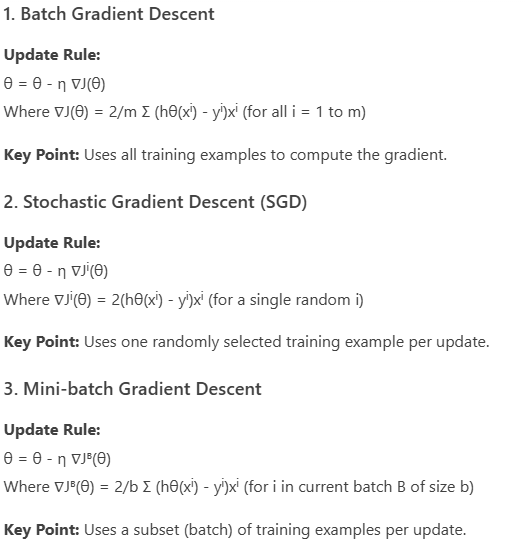

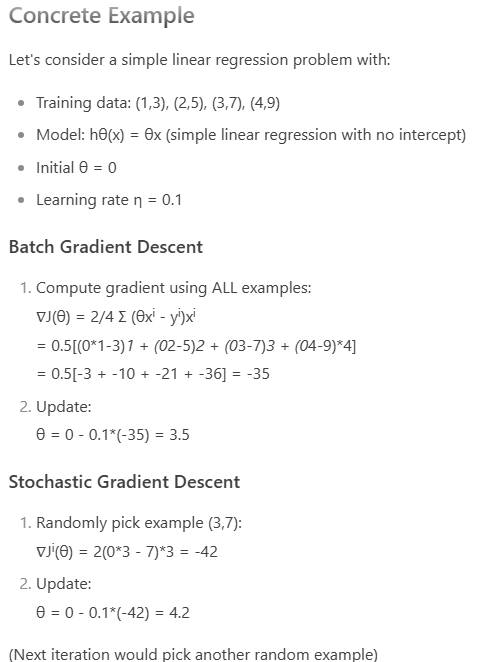

**Let's implement vanilla gradient descent to find the minimum of a simple quadratic function f(x) = x² + 5x + 6.**

Minimum occurs at x = -2.5000
Minimum value f(x) = -0.2500


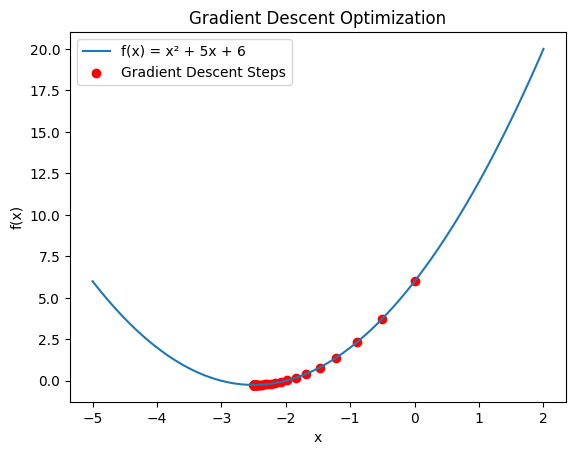

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + 5*x + 6

def df(x):
    return 2*x + 5  # Derivative of f(x)

def gradient_descent(initial_x, learning_rate, n_iterations):
    x = initial_x
    history = [x]

    for _ in range(n_iterations):
        grad = df(x)
        x = x - learning_rate * grad
        history.append(x)

    return x, history

# Parameters
initial_x = 0
learning_rate = 0.1
n_iterations = 100

# Run gradient descent
optimal_x, history = gradient_descent(initial_x, learning_rate, n_iterations)

print(f"Minimum occurs at x = {optimal_x:.4f}")
print(f"Minimum value f(x) = {f(optimal_x):.4f}")

# Visualization
x_vals = np.linspace(-5, 2, 100)
plt.plot(x_vals, f(x_vals), label='f(x) = x² + 5x + 6')
plt.scatter(history, [f(x) for x in history], c='red', label='Gradient Descent Steps')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title('Gradient Descent Optimization')
plt.show()

##Types of Gradient Descent

1. Batch Gradient Descent

Uses the entire training dataset to compute the gradient at each step

Pros: Stable convergence, deterministic

Cons: Computationally expensive for large datasets

In [2]:
def batch_gradient_descent(X, y, theta, learning_rate, n_iterations):
    m = len(y)
    cost_history = []

    for _ in range(n_iterations):
        gradients = 2/m * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
        cost = np.mean((X.dot(theta) - y)**2)
        cost_history.append(cost)

    return theta, cost_history

2. Stochastic Gradient Descent (SGD)
Uses a single random training example to compute the gradient at each step

Pros: Faster updates, can escape local minima

Cons: Noisy updates, may not converge as smoothly

In [3]:
def stochastic_gradient_descent(X, y, theta, learning_rate, n_epochs):
    m = len(y)
    cost_history = []

    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]

            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients

        cost = np.mean((X.dot(theta) - y)**2)
        cost_history.append(cost)

    return theta, cost_history

3. Mini-batch Gradient Descent
Compromise between batch and stochastic

Uses a small random subset (mini-batch) of the data at each step

Most commonly used in practice

In [4]:
def mini_batch_gradient_descent(X, y, theta, learning_rate, n_epochs, batch_size):
    m = len(y)
    cost_history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]

            gradients = 2/batch_size * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients

        cost = np.mean((X.dot(theta) - y)**2)
        cost_history.append(cost)

    return theta, cost_history

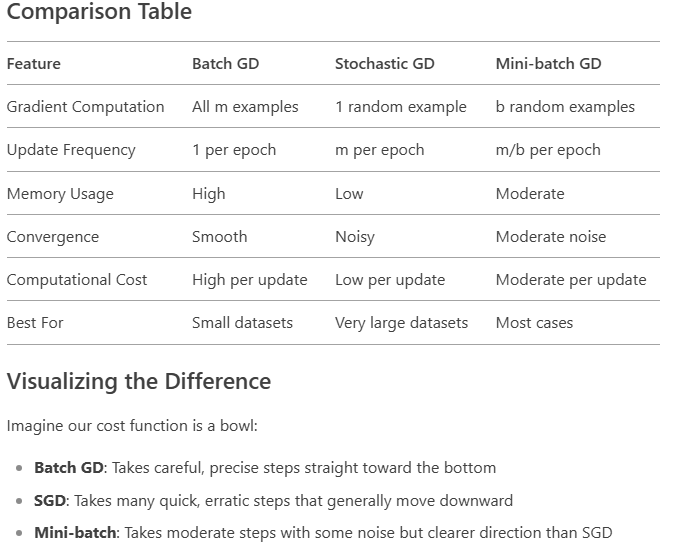

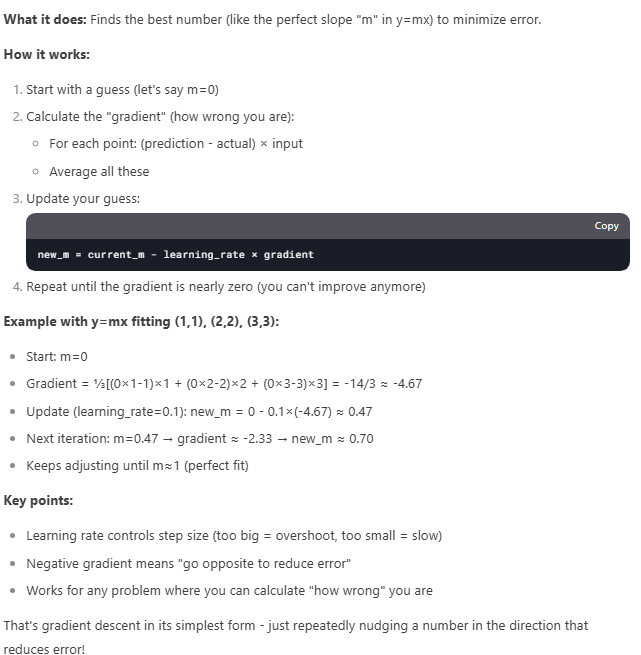